##### GoogleNet (inception) Pre-trained Keras Implementation

###### Imports

In [13]:
import tensorflow as tf
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input,decode_predictions
import numpy as np
from matplotlib import pyplot as plt

###### Loading Pre-trained Model

In [2]:
# Load the pre-trained InceptionV3 model
model = InceptionV3(weights='imagenet')

# Display model summary
model.summary()

96112376/96112376 ━━━━━━━━━━━━━━━━━━━━ 24s 0us/step


Model: "inception_v3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 299, 299,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 149, 149,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 149, 149,  │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 149, 149,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 147, 147,  │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 147, 147,  │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 147, 147,  │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 147, 147,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 73, 73,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 73, 73,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 73, 73,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 73, 73,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 71, 71,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 71, 71,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 71, 71,    │          0 │ batch_normalizat

 Total params: 23,851,784 (90.99 MB)

 Trainable params: 23,817,352 (90.86 MB)

 Non-trainable params: 34,432 (134.50 KB)

###### Model Inferencing

In [14]:
from tensorflow.keras.utils import load_img,img_to_array

In [17]:
# Predict Function
def predict_function(model,image_path):
    img = load_img(image_path,target_size=(299,299))

    img_array = img_to_array(img)

    img_array = np.expand_dims(img_array,axis=0)

    img_array = preprocess_input(img_array)

    predictions = model.predict(img_array)

    decoded_predictions = decode_predictions(predictions,top=5)
    
    return decoded_predictions[0] 

###### Visualizing Results

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Predictions:
1: fox_squirrel (0.35)
2: Egyptian_cat (0.08)
3: tiger_cat (0.03)
4: lynx (0.02)
5: grey_fox (0.01)


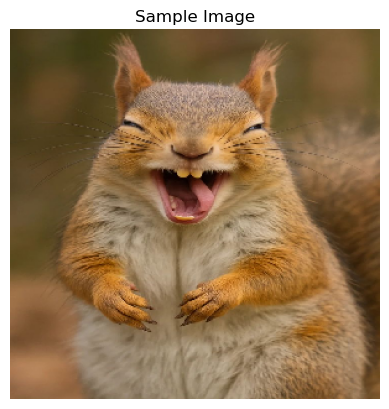

In [18]:
sample_image_path = 'squirrel.jpg'

predictions = predict_function(model,sample_image_path)

print('Predictions:')
for i,(imagenet_id,label,score) in enumerate(predictions):
    print(f'{i+1}: {label} ({score:.2f})')

# Visualize the sample image
img = load_img(sample_image_path,target_size=(299,299))
plt.imshow(img)
plt.title('Sample Image')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 337ms/step
Predictions:
1: starfish (1.00)
2: sea_urchin (0.00)
3: power_drill (0.00)
4: totem_pole (0.00)
5: hook (0.00)


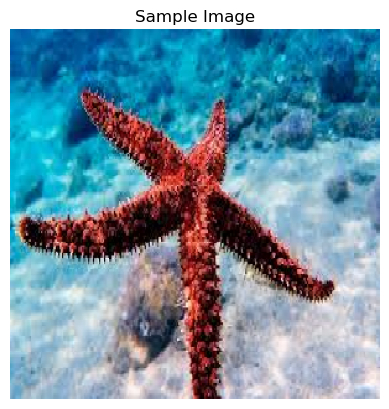

In [20]:
sample_image_path = 'starfish.jpg'

predictions = predict_function(model,sample_image_path)

print('Predictions:')
for i,(imagenet_id,label,score) in enumerate(predictions):
    print(f'{i+1}: {label} ({score:.2f})')

# Visualize the sample image
img = load_img(sample_image_path,target_size=(299,299))
plt.imshow(img)
plt.title('Sample Image')
plt.axis('off')
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
Predictions:
1: bustard (0.95)
2: remote_control (0.00)
3: ostrich (0.00)
4: black_grouse (0.00)
5: screw (0.00)


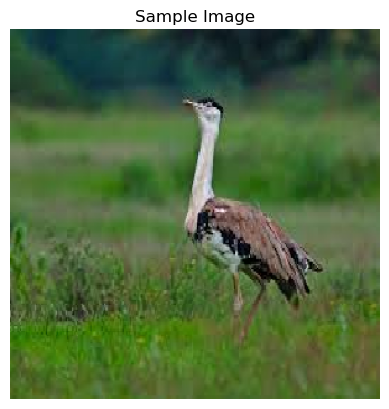

In [21]:
sample_image_path = 'indian-bustard.jpg'

predictions = predict_function(model,sample_image_path)

print('Predictions:')
for i,(imagenet_id,label,score) in enumerate(predictions):
    print(f'{i+1}: {label} ({score:.2f})')

# Visualize the sample image
img = load_img(sample_image_path,target_size=(299,299))
plt.imshow(img)
plt.title('Sample Image')
plt.axis('off')
plt.show()
